In [1]:
import scipy.io
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Audio
from soundsig.signal import bandpass_filter
from soundsig.sound import spectrogram, plot_spectrogram, log_transform

In [2]:
# Define constants

DATA_KEYS = ["Raw_wave", "FS", "Piezo_wave", "Piezo_FS"] # Keys for *.mat
LABEL_KEYS = ["IndVocStartRaw", "IndVocStartPiezo", "IndVocStopRaw", "IndVocStopPiezo"] # Keys for *_200.mat
WIN = 100 # Window length in ms
OVER = 10 # Overlap length in ms
FMIN = 100 # Min frequency in Hz
FMAX = 5000 # Max frequency in Hz

In [3]:
# Accessor functions

def load_mat(filename):
    """
    This function should be called instead of scipy.io.loadmat
    as it can recover python dictionaries from mat files.
    """
    def _check_keys(d):
        """
        Checks if entries in dictionary are mat-objects. If yes
        todict is called to change them to nested dictionaries
        """
        for key in d:
            if isinstance(d[key], scipy.io.matlab.mio5_params.mat_struct):
                d[key] = _todict(d[key])
        return d

    def _todict(matobj):
        """
        A recursive function which constructs from matobjects nested dictionaries
        """
        d = {}
        for strg in matobj._fieldnames:
            elem = matobj.__dict__[strg]
            if isinstance(elem, scipy.io.matlab.mio5_params.mat_struct):
                d[strg] = _todict(elem)
            else:
                d[strg] = elem
        return d
    
    data = scipy.io.loadmat(filename, struct_as_record=False, squeeze_me=True)
    return _check_keys(data)


def get_raw_wave_at_section(data_file, section):
    """
    Gets section SECTION of Raw_wave from ndarray DATA_FILE.
    """
    return data_file["Raw_wave"][section]


def get_raw_fs(data_file):
    """
    Gets sampling rate of ndarray DATA_FILE.
    """
    return data_file["FS"]


def get_piezo_fs(data_file, logger_id):
    """
    Gets sampling rate of the piezo LOGGER_ID from ndarray DATA_FILE.
    """
    return data_file["Piezo_FS"][logger_id][0]


def get_piezo_wave_at_section(data_file, logger_id, section):
    """
    Gets Piezo_wave of piezo LOGGER_ID from ndarray DATA_FILE at section SECTION.
    """
    return data_file["Piezo_wave"][logger_id][section]


def get_label_at_section(label_file, key, piezo_ind, section):
    """
    Gets labels of piezo indexed PIEZO_IND from ndarray LABEL_FILE at section SECTION.
    KEY should be in LABEL_KEYS.
    """
    result = label_file[key][section]
    if result.size == 0:
        return result
    else:
        return result[piezo_ind]
    

def get_label_start_stop_at_section(label_file, piezo_ind, section, start_key, end_key):
    """
    Gets the start and stop indices of the labels of the piezo indexed PIEZO_IND
    from LABEL_FILE. START_KEY and END_KEY should be in LABEL_KEYS.
    """
    start_labels = get_label_at_section(label_file, start_key, piezo_ind, section)
    s = start_labels.size
    if s == 0:
        return start_labels
    else:
        stop_labels = get_label_at_section(label_file, end_key, piezo_ind, section)
        result = np.zeros((s, 2))
        for i in range(s):
            result[i][0] = start_labels[i]
            result[i][1] = stop_labels[i]
        return result
    
        
def label_inds_to_seconds(labels, sr):
    """
    Given sample rate SR, converts label indices in LABELS to seconds.
    """
    return labels / sr


def get_mapping(data_file):
    """
    Gets two-way mapping between piezo indices and logger ID's for DATA_FILE.
    """
    ind_to_id, id_to_ind = {}, {}
    i = 0
    for key in data_file["Piezo_wave"]:
        ind_to_id[i] = key
        id_to_ind[key] = i
        i += 1
    return ind_to_id, id_to_ind

In [4]:
# Feature extraction functions

def bandpass(wave, sr):
    """
    Applies bandpass filter to WAVE at sampling rate SR. See soundsig for more info
    """
    return bandpass_filter(wave, sr, FMIN, FMAX)


def generate_spectrogram(wave, sr):
    """
    Generates spectrogram for WAVE at sampling rate SR. See soundsig for more info
    """
    t, f, spec, spec_rms = spectrogram(s=wave, 
                                 sample_rate=sr, 
                                 spec_sample_rate=1000/OVER, 
                                 freq_spacing=1000/WIN,
                                 min_freq=FMIN,
                                 max_freq=FMAX,
                                 nstd=6,
                                 cmplx=False,
                                )
    return t, f, spec, spec_rms

In [5]:
import os

In [12]:
root = os.getcwd()
# The files that we want to read
data_filename = root + "/UMAP/20190213/190213_1101_VocExtractData.mat"
label_filename = root + "/UMAP/20190213/190213_1101_VocExtractData_200.mat"

# Load files and their sample rates
data_file = load_mat(data_filename)
label_file = load_mat(label_filename)

# Create two-way mapping between indices and logger ID's
ind_to_id, id_to_ind = get_mapping(data_file)
print("Piezo index to logger ID:\n", ind_to_id)
print("\nLogger ID to piezo index:\n", id_to_ind)

Piezo index to logger ID:
 {0: 'Logger3', 1: 'Logger6'}

Logger ID to piezo index:
 {'Logger3': 0, 'Logger6': 1}


In [30]:
# The logger ID
logger_id = "Logger3"

# The section index. section_num is in range(100)
section_num = 13

# Get piezo_wave and sampling rate
wave = get_piezo_wave_at_section(data_file, logger_id, section_num)
sr = get_piezo_fs(data_file, logger_id)

# Play the audio
Audio(wave, rate=sr)


In [21]:
piezo_ind = id_to_ind[logger_id]
print(piezo_ind)
print(piezo_ind, section_num, LABEL_KEYS[1], LABEL_KEYS[3])
labels = get_label_start_stop_at_section(label_file, piezo_ind, section_num, "IndVocStartPiezo_merged", LABEL_KEYS[3])
start_stop_seconds = label_inds_to_seconds(labels, sr)
for i in range(len(start_stop_seconds)):
    elem = start_stop_seconds[i]
    print("vocalization {}: {:.2f}s to {:.2f}s".format(i, elem[0], elem[1]))

0
0 13 IndVocStartPiezo IndVocStopPiezo


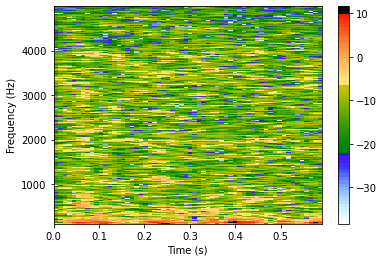

In [29]:
# Apply bandpass filter
filtered = bandpass(wave, sr)

# Generate the spectrogram
t, f, spec, spec_rms = generate_spectrogram(filtered, sr)

# Plot the spectrogram
plot_spectrogram(t, f, spec)

In [7]:
print("string", 12)

string 12
